## Load notebook

### Python modules

In [1]:
# standard libs
import numpy as np
import pandas as pd
from scipy import sparse
import lmfit as lm
from tqdm import tqdm
import io, sys, importlib
from contextlib import redirect_stdout

# matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
plt.rcParams['font.size'], plt.rcParams['axes.labelsize'] = 14, 18

# XPCS library
sys.path.append('./XPCSlibrary/')

import ID10tools as ID10
from ID10tools import Nx, Ny, Npx
importlib.reload(ID10)
ID10.set_version('v2')

import XPCStools as XPCS
from XPCStools import E2lambda, lambda2E, theta2Q, Q2theta, decorrelation_f
importlib.reload(XPCS)
XPCS.set_beamline('ID10')

import COSMICRAYtools as COSMIC
importlib.reload(COSMIC)
COSMIC.set_beamline('ID10')

#### EXPERIMENTAL VARIABLES ####
XPCS.set_expvar(1350, 1350, 7.1)
ID10.Nfmax_dense_file = 2000
ID10.Nfmax_sparse_file = 5000
################################

###### FOLDER PATHS ######
from folder_paths import *
##########################

### Load e4m masks

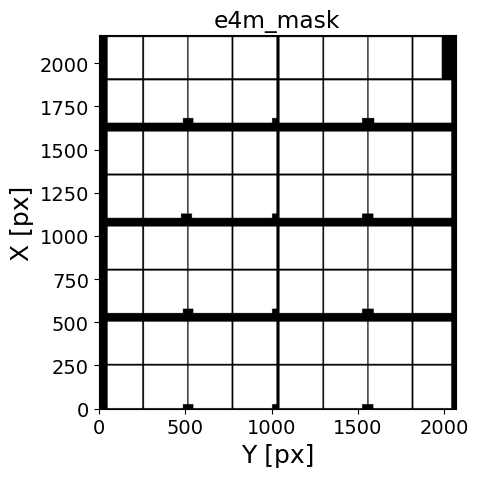

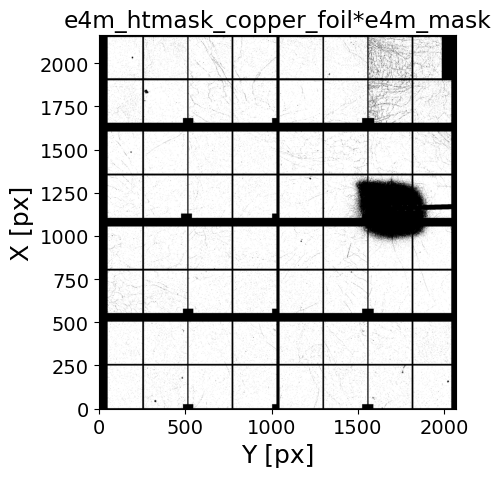

In [2]:
### e4m MASKS
e4m_htmask_copper_foil = np.load(MASKS_folder+'e4m_htmask_copper_foil_30um_1_1'+'.npy')
e4m_mask = np.load(MASKS_folder+'e4m_mask'+'.npy')

plt.figure(figsize=(5, 5))
plt.imshow((e4m_mask).reshape(Nx,Ny), cmap='gray', origin='lower')
plt.xlabel('Y [px]')
plt.ylabel('X [px]')
plt.title('e4m_mask')
plt.tight_layout(); plt.show()

plt.figure(figsize=(5, 5))
plt.imshow((e4m_htmask_copper_foil*e4m_mask).reshape(Nx,Ny), cmap='gray', origin='lower')
plt.xlabel('Y [px]')
plt.ylabel('X [px]')
plt.title('e4m_htmask_copper_foil*e4m_mask')
plt.tight_layout()

## Choose XPCS scan 4 analyisis

In [3]:
#######################################
sample_name = 'GeO2_7_170C'
Ndataset = 1
Nscan = 3
#######################################

## Beamstop mask

In [4]:
#######################################
Nfi, Nff = 0, 1000
#######################################

scan = ID10.load_scan(RAW_folder, sample_name, Ndataset, Nscan)
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)

print('#############################')
print('command =', scan['command'])
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('#############################\n')

e4m_data = ID10.load_sparse_e4m(RAW_folder, sample_name, Ndataset, Nscan, Nfi, Nff,  n_jobs=1, )

#############################
command = mtimescan 0.001 1 1800288
Ei = 9.699998837562536
itime = 0.0011
theta = 1.7500000000000004
Q = 0.15
#############################

Loading sparse array ...
	 -> loading file eiger4m_v2_sparse_frame_0_00000.h5 (1/1 loops)
Done! (elapsed time = 0.06 s)
Concatenating vectors ...
Done! (elapsed time = 0.01 s)
	 | Sparse array loaded from ../RAW_DATA/GeO2_7_170C/GeO2_7_170C_0001/scan0003/
	 | Shape:       (1000, 4471016)
	 | Sparsity:     2.2e-04
	 | Memory usage (scipy.csr_array): 0.011 GB (np.array usage: 16.656 GB)


################################################################################
Maximum count in the whole run -> 242.0
# of pixels above Ith_high treshold ->  864277 pixels (of 4471016 => 19.33 %)
################################################################################



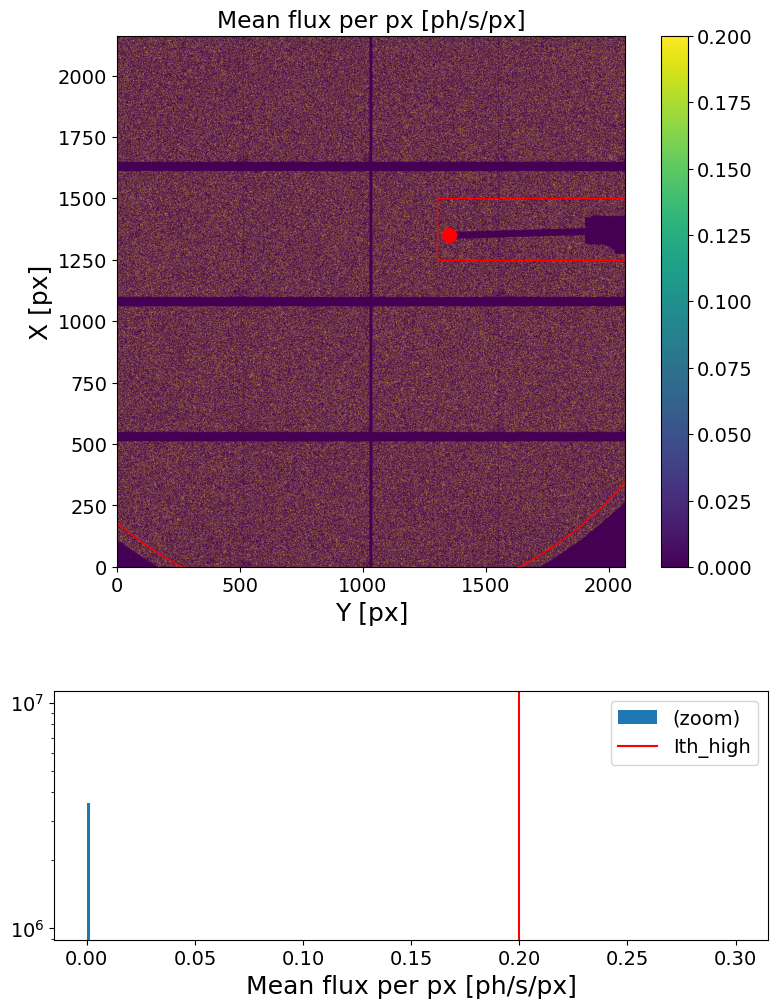

In [5]:
geom = [{'geom':'Rectangle', 'x0':1250, 'y0':1300, 'xl':250, 'yl':1950, 'inside':False},
        {'geom':'Circle', 'Cx':1300, 'Cy':950, 'r':1470, 'inside':True}, 
        ]
XPCS.gen_plots4mask(e4m_data, itime, Ith_high=.2, mask_geom=geom,)

#################################################
Masked area =  93.74594052000708 %
#################################################



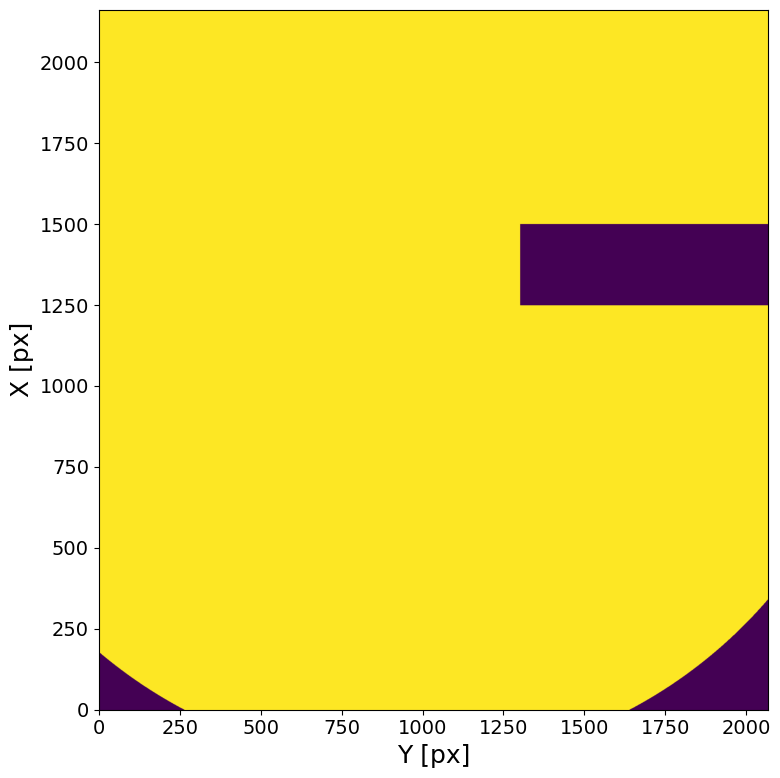

In [6]:
bs_mask = XPCS.gen_mask(mask_geom=geom)

## XPCS scan X-Y analysis

### Load full scan

In [7]:
#######################################
Nfi, Nff = 1000, None
#######################################

scan = ID10.load_scan(RAW_folder, sample_name, Ndataset, Nscan)
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)

print('#############################')
print('command =', scan['command'])
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('T = {:.2f} min'.format(len(scan['fast_timer_period'])*itime/60))   
print('#############################\n')

e4m_data = ID10.load_sparse_e4m(RAW_folder, sample_name, Ndataset, Nscan, Nfi, Nff,  n_jobs=50)
e4m_data = COSMIC.fast_gamma_filter(e4m_data, Imaxth_high=4)

#############################
command = mtimescan 0.001 1 1800288
Ei = 9.699998837562536
itime = 0.0011
theta = 1.7500000000000004
Q = 0.15
T = 33.01 min
#############################

Loading sparse array ...
	 -> loading file eiger4m_v2_sparse_frame_0_00008.h5 (9/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00015.h5 (16/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00001.h5 (2/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00000.h5 (1/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00003.h5 (4/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00005.h5 (6/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00002.h5 (3/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00009.h5 (10/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00004.h5 (5/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00006.h5 (7/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00010.h5 (11/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00014.

### Intensity analysis

In [8]:
####################
Lbin = 10
Nstep = 100
mask = None #e4m_mask*e4m_htmask*bs_mask*Qmask
####################

It = np.vstack(XPCS.get_It(e4m_data, itime, mask=mask, Lbin=Lbin, Nstep=Nstep))

<SecondaryAxis: >

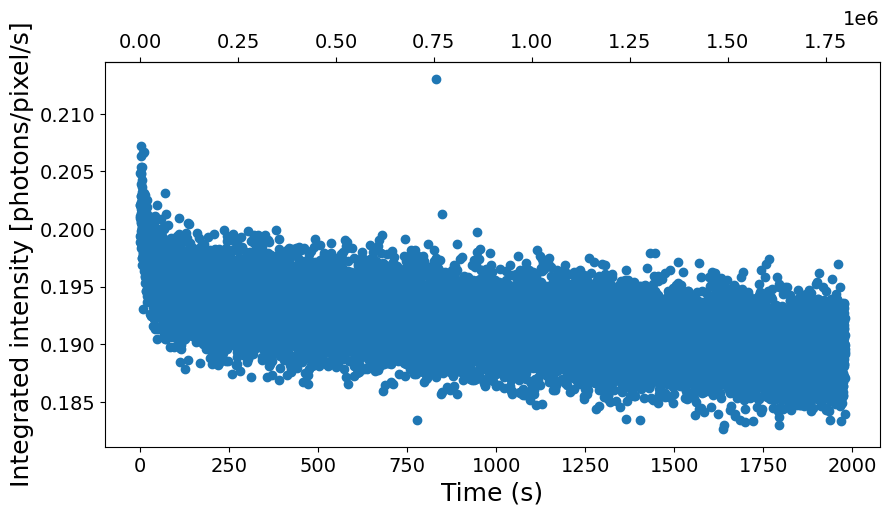

In [9]:
plt.figure(figsize=(10,5))
plt.scatter(It[0], It[1], label='It')
plt.xlabel('Time (s)')
plt.ylabel('Integrated intensity [photons/pixel/s]')
plt.gca().secondary_xaxis('top', functions=(lambda x: x/itime, lambda x: x*itime))
#plt.xlim(0, 3000)

### Flux profile with mask=e4m_mask*bs_mask

################################################################################
Maximum count in the whole run -> 4.0
# of pixels above Ith_high treshold ->  257006 pixels (of 4471016 => 7.41 %)
# of pixels below Ith_low treshold ->  220032 pixels (of 4471016 => 6.34 %)
################################################################################



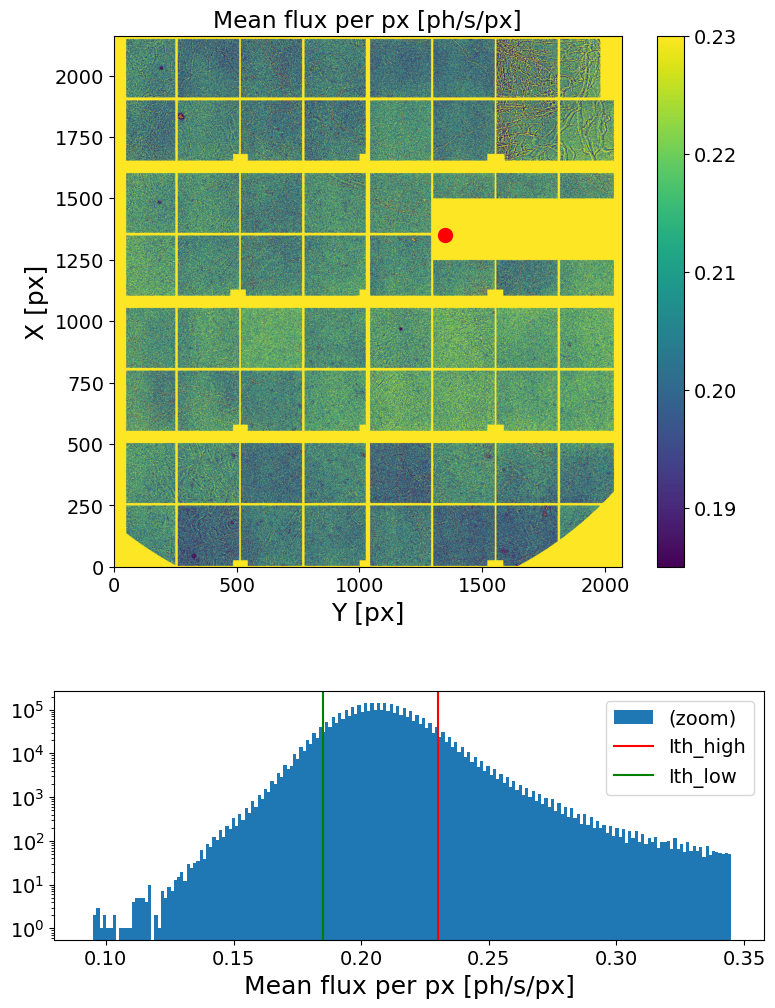

In [10]:
##################
Ith_low=.185
Ith_high=.23
##################
 
XPCS.gen_plots4mask(e4m_data, itime, Ith_low=Ith_low, Ith_high=Ith_high, Nfi=0, Nff=None, mask=e4m_mask*bs_mask)

### Flux profile with mask = e4m_mask * bs_mask * e4m_htmask_copper_foil

################################################################################
Maximum count in the whole run -> 4.0
# of pixels above Ith_high treshold ->  220931 pixels (of 4471016 => 6.64 %)
# of pixels below Ith_low treshold ->  193276 pixels (of 4471016 => 5.81 %)
################################################################################



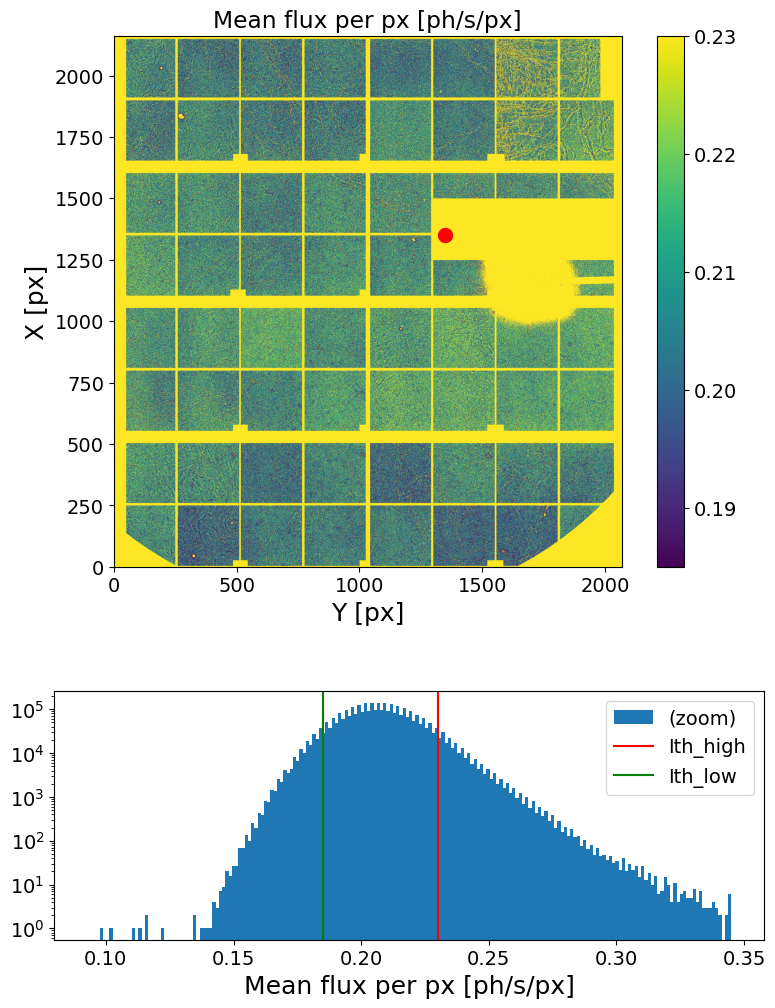

In [11]:
XPCS.gen_plots4mask(e4m_data, itime, Ith_low=Ith_low, Ith_high=Ith_high, Nfi=0, Nff=None, mask=e4m_mask*bs_mask*e4m_htmask_copper_foil)

### Mask generation

#################################################
Masked area =  66.92935118102909 %
#################################################



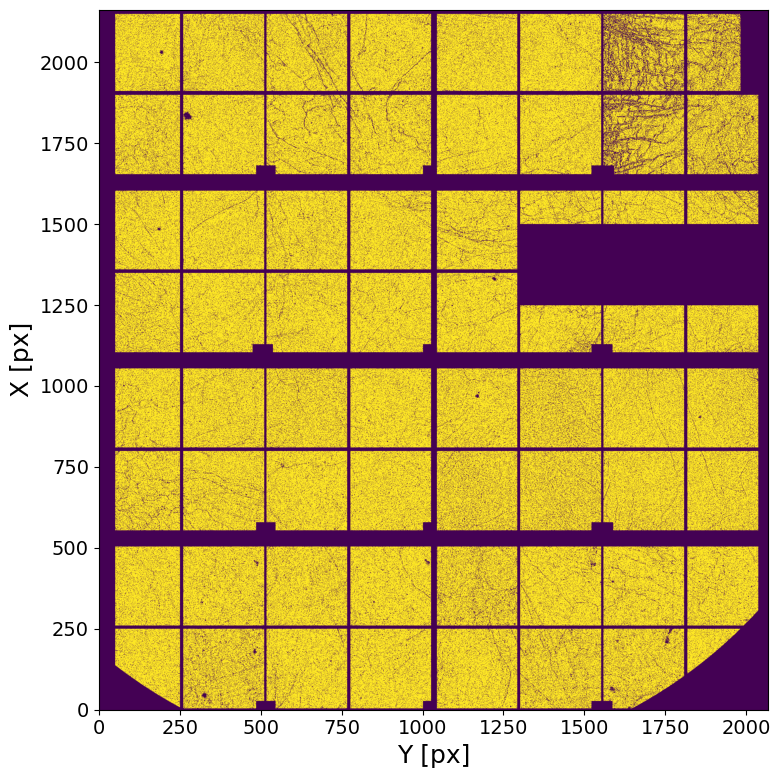

In [12]:
e4m_htmask = XPCS.gen_mask(e4m_data=e4m_data, itime=itime, mask=e4m_mask*bs_mask, Ith_high=Ith_high, Ith_low=Ith_low, Nfi=None, Nff=None, hist_plots=False)
np.save(MASKS_folder  + f'e4m_htmask-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}.npy', e4m_htmask)

## Test

### Q mask 4 testing

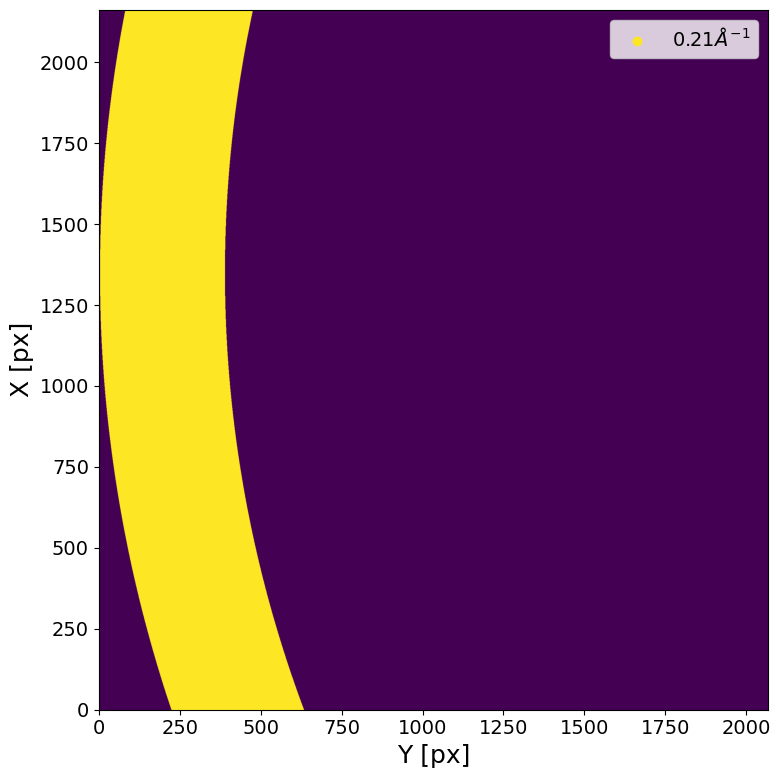

In [13]:
###################
Q_notebook = .21 # [.21, .19, .17, .15, .13]
dQ_notebook = .01 # => Q_width = 2*dQ
###################

Qmask = XPCS.gen_Qmask(Ei, theta, Q_notebook, dQ_notebook, Qmap_plot=False)

### Load full test scan

In [14]:
#######################################
sample_name = 'GeO2_3_240C'
Ndataset = 1
Nscan = 4
Nfi, Nff = 1000, None
#######################################

scan = ID10.load_scan(RAW_folder, sample_name, Ndataset, Nscan)
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)

print('#############################')
print('command =', scan['command'])
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('T = {:.2f} min'.format(len(scan['fast_timer_period'])*itime/60))   
print('#############################\n')

e4m_data = ID10.load_sparse_e4m(RAW_folder, sample_name, Ndataset, Nscan, Nfi, Nff,  n_jobs=50)
e4m_data = COSMIC.fast_gamma_filter(e4m_data, Imaxth_high=4)

#############################
command = mtimescan 0.001 1 1500240
Ei = 9.699998837562536
itime = 0.0011
theta = 1.7500000000000004
Q = 0.15
T = 27.50 min
#############################

Loading sparse array ...
	 -> loading file eiger4m_v2_sparse_frame_0_00000.h5 (1/301 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00044.h5 (45/301 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00002.h5 (3/301 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00033.h5 (34/301 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00017.h5 (18/301 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00019.h5 (20/301 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00024.h5 (25/301 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00001.h5 (2/301 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00047.h5 (48/301 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00007.h5 (8/301 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00003.h5 (4/301 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_000

### Intensity analysis

In [15]:
####################
Lbin = 10
Nstep = 100
mask = e4m_mask*e4m_htmask*bs_mask
####################

It = np.vstack(XPCS.get_It(e4m_data, itime, mask=mask, Lbin=Lbin, Nstep=Nstep))

<SecondaryAxis: >

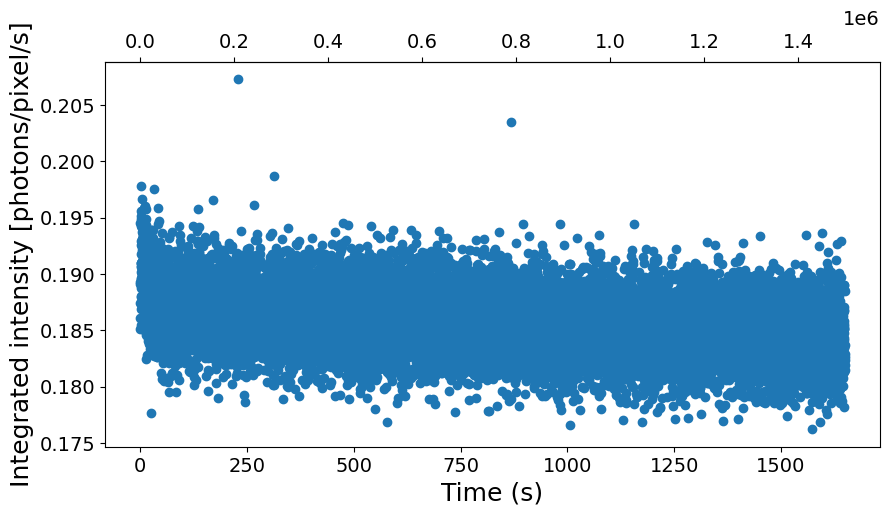

In [16]:
plt.figure(figsize=(10,5))
plt.scatter(It[0], It[1], label='It')
plt.xlabel('Time (s)')
plt.ylabel('Integrated intensity [photons/pixel/s]')
plt.gca().secondary_xaxis('top', functions=(lambda x: x/itime, lambda x: x*itime))
#plt.xlim(0, 3000)

### Flux profile with mask=e4m_mask*bs_mask

################################################################################
Maximum count in the whole run -> 4.0
# of pixels above Ith_high treshold ->  4225 pixels (of 4471016 => 0.12 %)
################################################################################



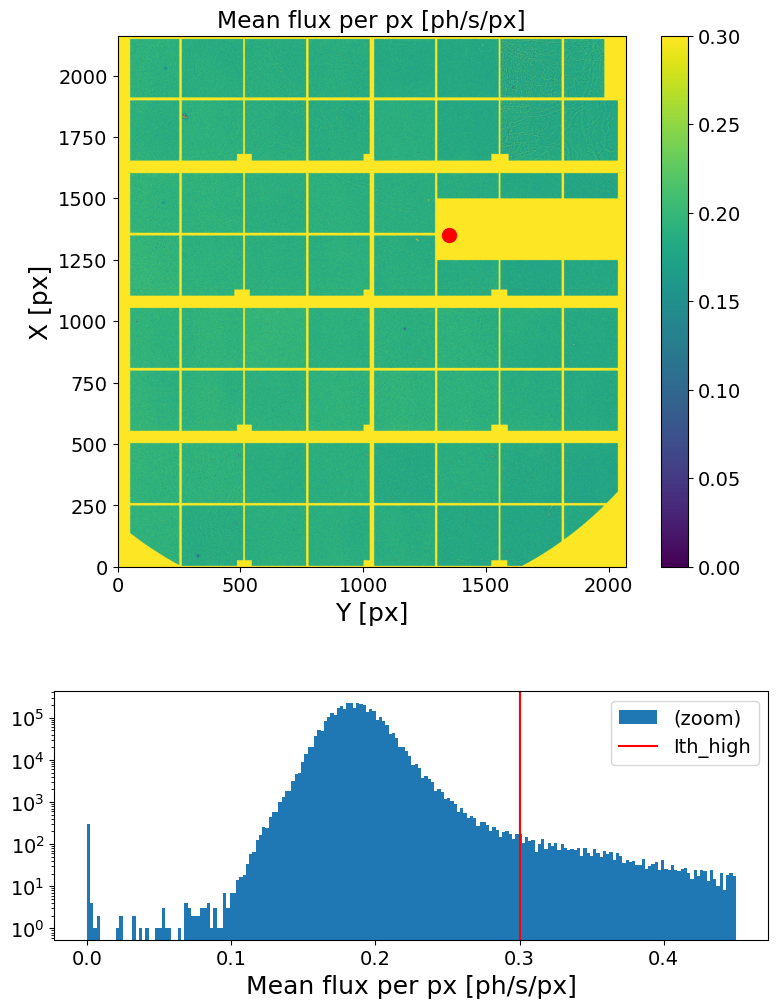

In [17]:
XPCS.gen_plots4mask(e4m_data, itime, Ith_low=None, Ith_high=.3, Nfi=None, Nff=None, mask=e4m_mask*bs_mask)

### Flux profile with mask = e4m_mask * bs_mask * e4m_htmask_copper_foil

################################################################################
Maximum count in the whole run -> 4.0
# of pixels above Ith_high treshold ->  137 pixels (of 4471016 => 0.0 %)
################################################################################



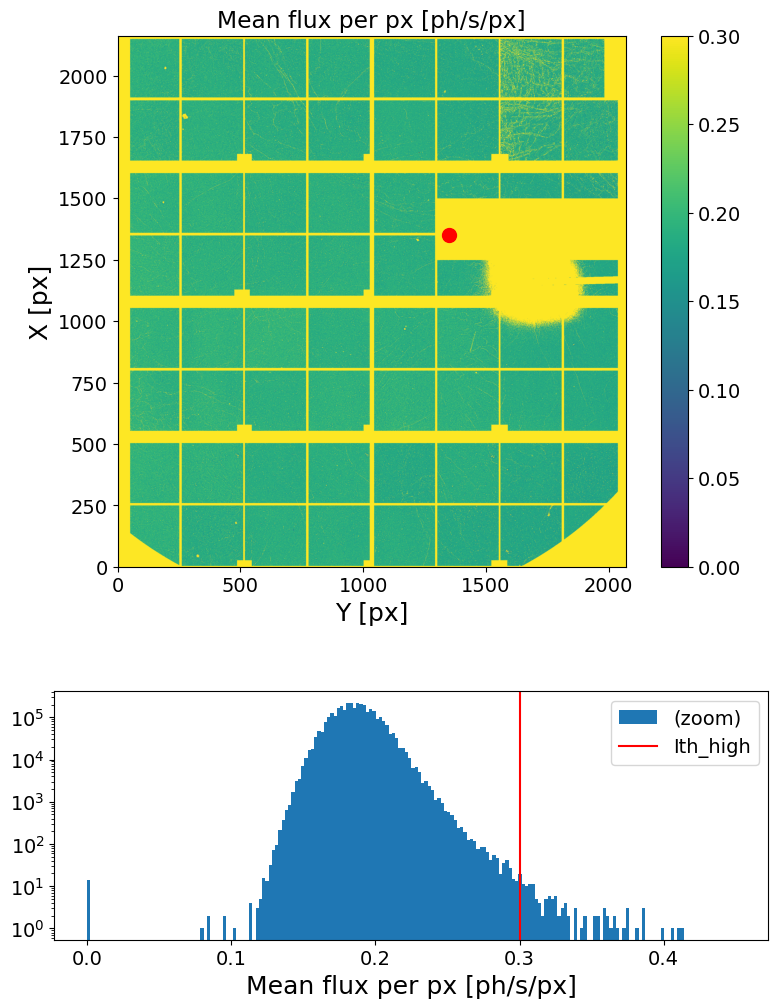

In [18]:
XPCS.gen_plots4mask(e4m_data, itime, Ith_low=None, Ith_high=.3, Nfi=None, Nff=None, mask=e4m_mask*bs_mask*e4m_htmask_copper_foil)

### Flux profile with mask = e4m_mask * bs_mask * e4m_htmask

################################################################################
Maximum count in the whole run -> 4.0
################################################################################



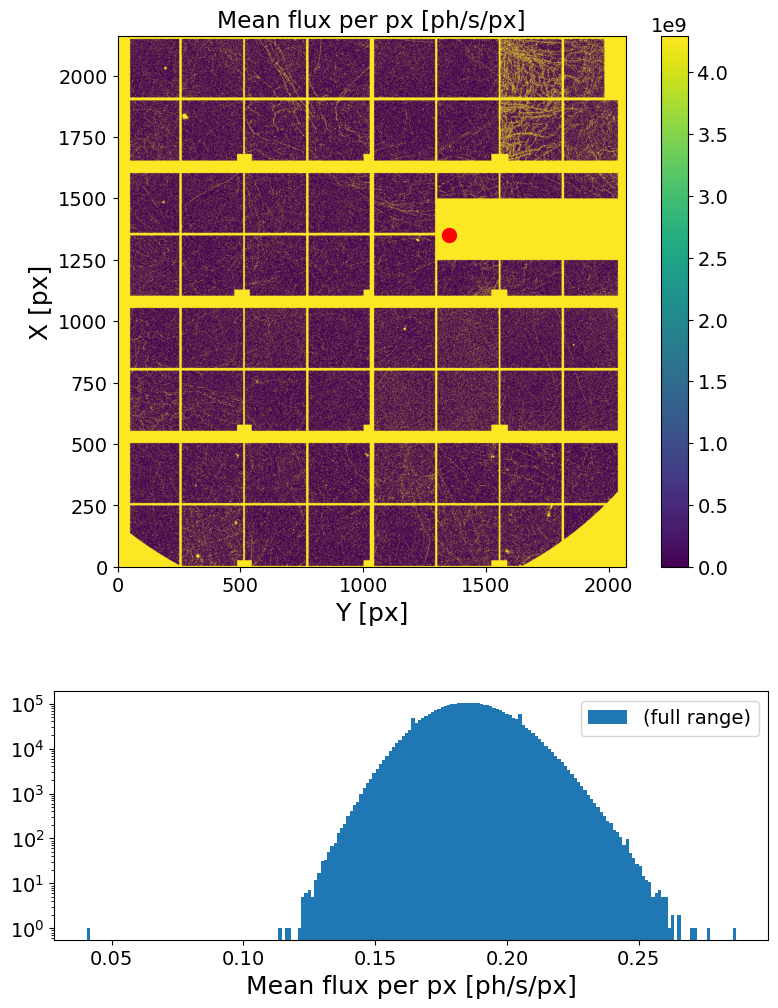

In [19]:
XPCS.gen_plots4mask(e4m_data, itime, Ith_low=None, Ith_high=None, Nfi=None, Nff=None, mask=e4m_mask*bs_mask*e4m_htmask)